In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
df = pd.read_csv("../outputs/recipes_cleaned.csv")
df["ingredients_normalized"] = df["ingredients_normalized"].apply(ast.literal_eval)
df.head(3)

,Unnamed: 0,Title,Ingredients,Instructions,Image_Name,Cleaned_Ingredients,has_image,ingredients_list,ingredients_normalized,ingredient_count
0,0,Miso-Butter Roast Chicken With Acorn Squash Pa...,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...","Pat chicken dry with paper towels, season all ...",miso-butter-roast-chicken-acorn-squash-panzanella,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...",True,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...","[whole chicken, salt, acorn squash, sage, rose...",21
1,1,Crispy Salt and Pepper Potatoes,"['2 large egg whites', '1 pound new potatoes (...",Preheat oven to 400°F and line a rimmed baking...,crispy-salt-and-pepper-potatoes-dan-kluger,"['2 large egg whites', '1 pound new potatoes (...",True,"['2 large egg whites', '1 pound new potatoes (...","[egg whites, pound new potatoes, teaspoons sal...",7
2,2,Thanksgiving Mac and Cheese,"['1 cup evaporated milk', '1 cup whole milk', ...",Place a rack in middle of oven; preheat to 400...,thanksgiving-mac-and-cheese-erick-williams,"['1 cup evaporated milk', '1 cup whole milk', ...",True,"['1 cup evaporated milk', '1 cup whole milk', ...","[evaporated milk, whole milk, garlic powder, o...",10


In [3]:
print(df["ingredient_count"].describe())

count    13489.000000
mean        10.639187
std          4.816725
min          1.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         51.000000
Name: ingredient_count, dtype: float64


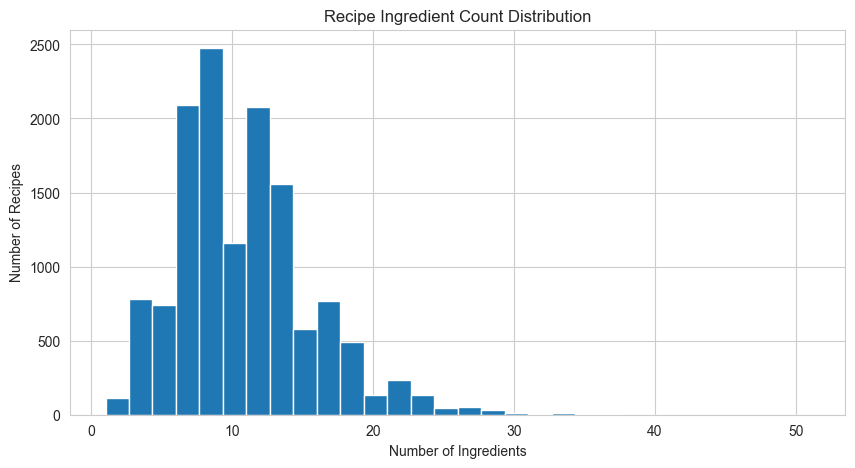

In [4]:
plt.hist(df["ingredient_count"], bins=30, edgecolor="white")
plt.title("Recipe Ingredient Count Distribution")
plt.xlabel("Number of Ingredients")
plt.ylabel("Number of Recipes")
plt.savefig("../outputs/fig_ingredient_count_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
suspicious = df[df["ingredient_count"] <= 2][["Title", "ingredients_normalized", "ingredient_count"]]
print(f"재료 2개 이하 레시피: {len(suspicious)}건")
suspicious.head(10)

재료 2개 이하 레시피: 112건


,Title,ingredients_normalized,ingredient_count
64,Fried Onions,"[vegetable oil, cooking onions]",2
130,Cooler-Steamed Corn,"[diamond crystal or morton salt, ears corn]",2
235,Cacao Water (Agua de Cacao),"[cacao beans, coconut water or bottled coconut...",2
371,Chinese Broccoli With Soy Paste,"[chinese broccoli or broccolini, soy paste]",2
459,Oysters with Balsamic,"[raw oysters, balsamic vinegar]",2
537,Fearless Sous Vide Poached Eggs,[eggs],1
746,Sesame Salt,"[white and or black sesame seeds, flaky sea salt]",2
767,Big-Batch Hard-Boiled Eggs,[eggs],1
882,Plain Popcorn,"[tablespoons vegetable oil, popcorn kernels]",2
883,Luscious Hot Chocolate,"[ounces semisweet chocolate, quarts milk]",2


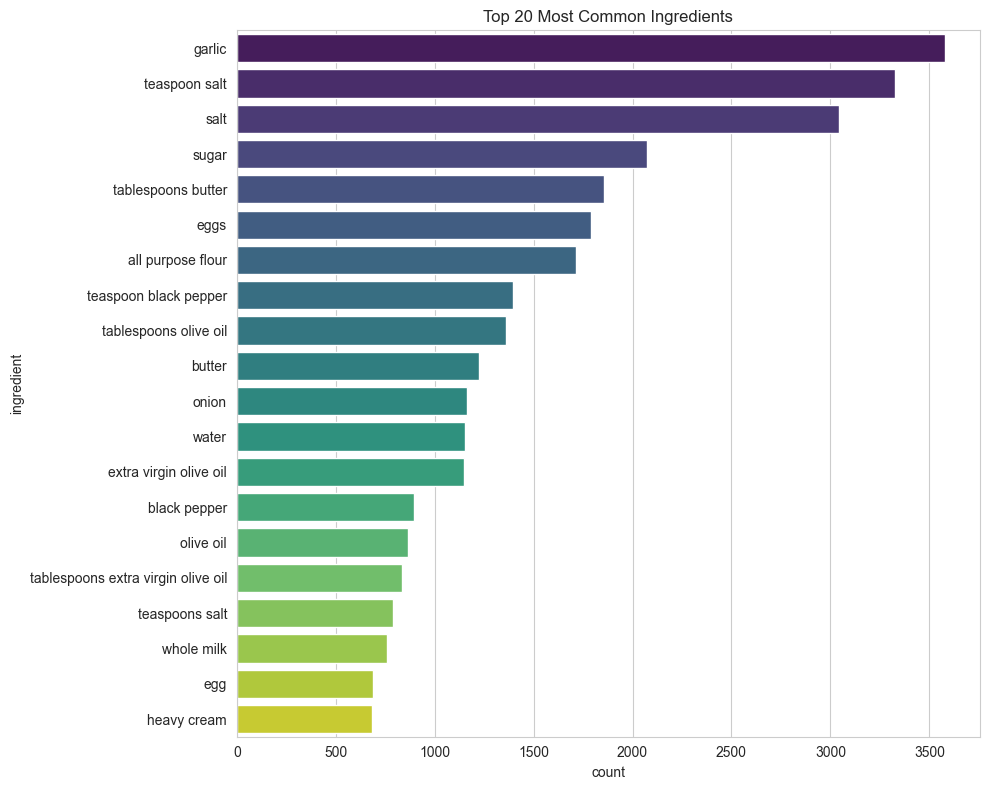

,ingredient,count
0,garlic,3577
1,teaspoon salt,3327
2,salt,3043
3,sugar,2074
4,tablespoons butter,1856
5,eggs,1792
6,all purpose flour,1716
7,teaspoon black pepper,1398
8,tablespoons olive oil,1361
9,butter,1226


In [6]:
all_ingredients = [ing for lst in df["ingredients_normalized"] for ing in lst]
ingredient_counter = Counter(all_ingredients)

top20 = ingredient_counter.most_common(20)
top20_df = pd.DataFrame(top20, columns=["ingredient", "count"])

plt.figure(figsize=(10, 8))
sns.barplot(data=top20_df, y="ingredient", x="count", hue="ingredient", palette="viridis", legend=False)
plt.title("Top 20 Most Common Ingredients")
plt.tight_layout()
plt.savefig("../outputs/fig_top20_ingredients.png", dpi=150, bbox_inches="tight")
plt.show()

top20_df

In [7]:
rare_ingredients = [ing for ing, cnt in ingredient_counter.items() if cnt == 1]
print(f"전체 고유 재료 수: {len(ingredient_counter)}")
print(f"딱 1번만 등장한 재료 수: {len(rare_ingredients)} ({len(rare_ingredients)/len(ingredient_counter)*100:.1f}%)")
print(rare_ingredients[:15])

전체 고유 재료 수: 30165
딱 1번만 등장한 재료 수: 22283 (73.9%)
['loaf white bread', 'full fat cream cheese', 'round italian loaf', 'turkey giblet stock or reduced sodium chicken broth', 'qt shallow ceramic or glass baking dish', 'teaspoons apple butter', 'garnish orange twist and grated or cinnamon', 'amaro averna', 'pat salted butter', 'hot apple cider', 'garnish pink peppercorns', 'turmeric syrup', 'garnish dehydrated lemon wheel', 'assorted dals', 'white jasmine rice or other long grain rice']


In [8]:
import random
random.seed(1)
sample_rare = random.sample(rare_ingredients, 20)
for r in sample_rare:
    print("-", r)

- pound smoked pork butt
- pound dried cannellini or great northern beans
- deep frying pan with a lid over heat
- ounce mint leaves
- beef drippings from roast beef
- coursely pecans
- pounds skinless boneless chicken
- ounces dried flat asian rice noodles
- daikon radish sprouts or other sprouts
- wide slices leeks
- aleppo pepper or tablespoons crushed red pepper flakes
- bone in pork blade or rib chops
- garnish lime wedge
- 240g butter
- ounces yellow wax beans
- pounds unpeeled size red skinned potatoes
- black pepper from the mill
- whole scotch bonnet pepper
- ounces romano beans or string beans
- ounce cans club soda


In [9]:
pair_counter = Counter()
sample_df = df.sample(n=min(3000, len(df)), random_state=42)

for lst in sample_df["ingredients_normalized"]:
    unique_ings = sorted(set(lst))
    for a, b in combinations(unique_ings, 2):
        pair_counter[(a, b)] += 1

top_pairs = pair_counter.most_common(15)
pairs_df = pd.DataFrame(
    [(a, b, cnt) for (a, b), cnt in top_pairs],
    columns=["ingredient_a", "ingredient_b", "count"]
)
pairs_df

,ingredient_a,ingredient_b,count
0,garlic,salt,222
1,all purpose flour,teaspoon salt,208
2,eggs,teaspoon salt,172
3,teaspoon black pepper,teaspoon salt,161
4,garlic,onion,151
5,all purpose flour,eggs,150
6,sugar,teaspoon salt,149
7,garlic,tablespoons olive oil,143
8,tablespoons butter,teaspoon salt,131
9,black pepper,salt,124


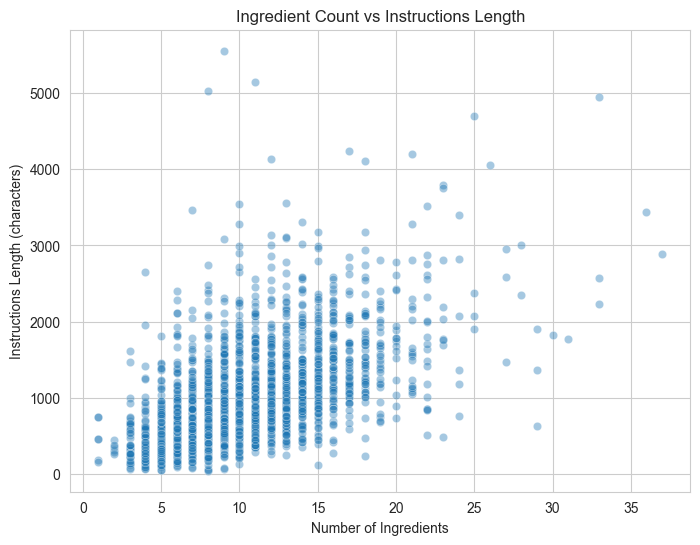

상관계수: 0.524


In [10]:
df["instructions_length"] = df["Instructions"].fillna("").astype(str).apply(len)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df.sample(min(2000, len(df)), random_state=1),
                 x="ingredient_count", y="instructions_length", alpha=0.4)
plt.title("Ingredient Count vs Instructions Length")
plt.xlabel("Number of Ingredients")
plt.ylabel("Instructions Length (characters)")
plt.savefig("../outputs/fig_complexity_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

correlation = df["ingredient_count"].corr(df["instructions_length"])
print(f"상관계수: {correlation:.3f}")

In [11]:
print("재료가 가장 적은 레시피 Top 5")
print(df.nsmallest(5, "ingredient_count")[["Title", "ingredient_count"]])

print()
print("재료가 가장 많은 레시피 Top 5")
print(df.nlargest(5, "ingredient_count")[["Title", "ingredient_count"]])

재료가 가장 적은 레시피 Top 5
                                Title  ingredient_count
537   Fearless Sous Vide Poached Eggs                 1
767        Big-Batch Hard-Boiled Eggs                 1
1376       Oven-Baked Sheet-Pan Bacon                 1
1778                       Nut Butter                 1
1858           Vegan Banana Ice Cream                 1

재료가 가장 많은 레시피 Top 5
                                                  Title  ingredient_count
3120              Epi's 50-Ingredient Super Bowl Nachos                51
4104  Beef Wellington with Roasted Potatoes and Wilt...                46
1009         Make-Ahead Freezer-to-Oven Chicken Packets                41
5242                                           Fat Rice                37
6708                                    Tandoori Turkey                37
